<a href="https://colab.research.google.com/github/JaySharma424/IndustryGPT-Specialized-LLM-Bot-Using-Pre-Trained-Models/blob/main/IndustryGPT_IT_Specialized_LLM_Bot.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Git Hub Link -  **https://github.com/JaySharma424/IndustryGPT-Specialized-LLM-Bot-Using-Pre-Trained-Models**

# IndustryGPT: Specialized LLM Bot for the IT Industry

### Capstone Project — Fine-Tuning a Pre-Trained Language Model

**Industry:** Technology & Information Technology (IT)

This notebook develops an industry-specific conversational bot using a pre-trained GPT-2 language model and Parameter-Efficient Fine-Tuning (LoRA). The project uses Stack Overflow programming questions as domain-specific data.

### Workflow
1. Project setup
2. Load the Stack Overflow dataset
3. Explore and clean the data
4. Create a manageable training sample
5. Analyze the dataset
6. Prepare Question → Answer prompts
7. Tokenize the data
8. Configure GPT-2 + LoRA
9. Fine-tune the model
10. Save the adapter
11. Build the chatbot
12. Test with IT-related queries
13. Save the final model

## 1. Project Objective

The objective is to build an **IT-specific LLM bot** capable of responding to programming and software-development questions.

The reference project uses the `pacovaldez/stackoverflow-questions` dataset and fine-tunes GPT-2 with LoRA. This notebook follows that same core approach while presenting it as one clean end-to-end workflow.

In [1]:
# Install the required libraries
!pip install -q transformers datasets accelerate peft beautifulsoup4 pandas matplotlib

In [2]:
# Imports
import os
import re
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from bs4 import BeautifulSoup
from datasets import load_dataset, Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    TrainingArguments,
    Trainer,
    pipeline
)
from peft import LoraConfig, get_peft_model, TaskType, PeftModel

import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Load the Industry Dataset

The project uses the **Stack Overflow Questions** dataset because it contains real-world programming questions and detailed technical descriptions.

Important fields:
- `title` — question title
- `body` — detailed question/problem description
- `label` — dataset category label

For Colab resource constraints, a small percentage of the training split is used for the fine-tuning workflow.

In [3]:
DATASET_NAME = "pacovaldez/stackoverflow-questions"

ds = load_dataset(DATASET_NAME)

print(ds)
print("\nAvailable splits:", list(ds.keys()))

README.md:   0%|          | 0.00/2.85k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/19 [00:00<?, ?it/s]

data/post_questions_train/post_questions(…): reconstructing file:   0%|          |  0.00B / 41.3MB            

data/post_questions_train/post_questions(…): downloading bytes:           |  0.00B            

...

data/post_questions_test/post_questions_(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/1572294 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/785098 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1570866 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['title', 'body', 'label'],
        num_rows: 1572294
    })
    validation: Dataset({
        features: ['title', 'body', 'label'],
        num_rows: 785098
    })
    test: Dataset({
        features: ['title', 'body', 'label'],
        num_rows: 1570866
    })
})

Available splits: ['train', 'validation', 'test']


In [4]:
# Inspect the training split
print(ds["train"].features)
print("\nNumber of training examples:", len(ds["train"]))

# Display a sample record
sample = ds["train"][0]

for key, value in sample.items():
    print(f"\n--- {key} ---")
    print(str(value)[:1000])

{'title': Value('string'), 'body': Value('string'), 'label': Value('int64')}

Number of training examples: 1572294

--- title ---
Parsing json directly using input stream

--- body ---
<p>I am doing a api call and in response i am getting json. So for that I want to parse it directly through input stream so that there would not be need of storing it in memory. 
For this I am trying to use JSONReader but that i am unable use for api's less than 11.
So i dont know how to proceed with. I want it to be done from 2.0 version onwards. Even parsing through JsonReader is not working.
I was thing of having GSON parser but i am not getting how to implement the same with Inputstream.</p>

<p>EDIT:
My code for the same:</p>

<pre><code>HttpClient client = new DefaultHttpClient();
HttpGet httpGet = new HttpGet(url);

try {
          HttpResponse response = client.execute(httpGet);
          StatusLine statusLine = response.getStatusLine();
          int statusCode = statusLine.getStatusCode();
    

## 3. Create a Manageable Training Sample

The original reference notebook uses a small sample to avoid Colab runtime and memory problems.

Here we make the sampling percentage configurable so the same notebook can be scaled up or down depending on available GPU memory.

In [5]:
# Configuration
SAMPLE_FRACTION = 0.01
SEED = 42

train_size = max(1, int(len(ds["train"]) * SAMPLE_FRACTION))

sampled_train = (
    ds["train"]
    .shuffle(seed=SEED)
    .select(range(train_size))
)

print("Original training examples:", len(ds["train"]))
print("Selected training examples:", len(sampled_train))

Original training examples: 1572294
Selected training examples: 15722


## 4. Data Cleaning

Basic preprocessing is performed:
- Remove missing titles and bodies
- Remove duplicate question records
- Remove HTML tags from question bodies
- Normalize unnecessary whitespace

The objective is to keep preprocessing simple and preserve the technical content of the Stack Overflow questions.

In [6]:
df = sampled_train.to_pandas()

print("Before cleaning:", df.shape)

print("\nMissing values:")
print(df[["title", "body"]].isnull().sum())

# Remove missing values
df = df.dropna(subset=["title", "body"]).copy()

# Remove duplicates
df = df.drop_duplicates(subset=["title", "body"]).copy()

def clean_text(text):
    text = BeautifulSoup(str(text), "html.parser").get_text(" ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["title"] = df["title"].apply(clean_text)
df["body"] = df["body"].apply(clean_text)

print("\nAfter cleaning:", df.shape)
df.head()

Before cleaning: (15722, 3)

Missing values:
title    0
body     0
dtype: int64


/tmp/ipykernel_4693/1453520167.py:15: MarkupResemblesLocatorWarning: The input passed in on this line looks more like a filename than HTML or XML.

If you meant to use Beautiful Soup to parse the contents of a file on disk, then something has gone wrong. You should open the file first, using code like this:

    filehandle = open(your filename)

You can then feed the open filehandle into Beautiful Soup instead of using the filename.

However, if you want to parse some data that happens to look like a filename, then nothing has gone wrong: you are using Beautiful Soup correctly, and this warning is spurious and can be filtered. To make this warning go away, run this code before calling the BeautifulSoup constructor:

    from bs4 import MarkupResemblesLocatorWarning
    import warnings

    warnings.filterwarnings("ignore", category=MarkupResemblesLocatorWarning)
    
  text = BeautifulSoup(str(text), "html.parser").get_text(" ")



After cleaning: (15722, 3)


,title,body,label
0,Imap search command to get the most recent mes...,Is there a command to do this? I can get messa...,2
1,Why is my UICollectionView cell not clickable ...,"I'm using UICollectionView in my swift class, ...",1
2,how to change front color of navigation bar title,I am using navigation controller in my applica...,0
3,& vs * and | vs +,"When doing boolean array comparison, is there ...",1
4,Using Gmail API to get Message Body with forma...,I have spent a few weeks on this now so I thou...,1


## 5. Dataset Exploration

Before training, inspect the label distribution to understand how the sampled dataset is distributed.

In [7]:
if "label" in df.columns:
    label_counts = df["label"].value_counts().sort_index()
    label_percentages = df["label"].value_counts(normalize=True).sort_index() * 100

    label_distribution = pd.DataFrame({
        "Frequency": label_counts,
        "Percentage": label_percentages.round(2)
    })

    display(label_distribution)
else:
    print("No label column available.")

,Frequency,Percentage
label,,
0,4026,25.61
1,3909,24.86
2,3917,24.91
3,3870,24.62


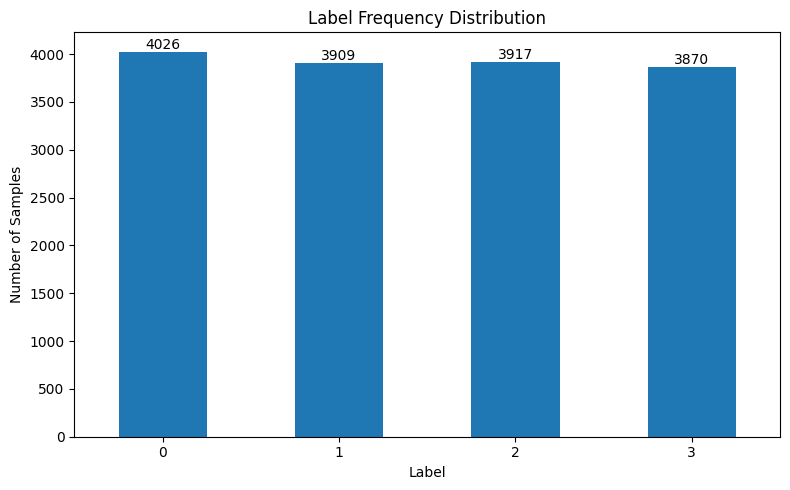

In [8]:
if "label" in df.columns:
    plt.figure(figsize=(8, 5))
    ax = label_distribution["Frequency"].plot(kind="bar")
    plt.title("Label Frequency Distribution")
    plt.xlabel("Label")
    plt.ylabel("Number of Samples")
    plt.xticks(rotation=0)

    for i, value in enumerate(label_distribution["Frequency"]):
        plt.text(i, value, str(value), ha="center", va="bottom")

    plt.tight_layout()
    plt.show()

## 6. Inspect Question Lengths

Question length analysis helps identify how much text is available before tokenization and truncation.

,title_words,body_words
count,15722.000000,15722.000000
mean,8.693423,154.948925
std,3.581596,151.635570
min,1.000000,6.000000
25%,6.000000,69.000000
50%,8.000000,114.000000
75%,11.000000,187.000000
max,32.000000,3033.000000


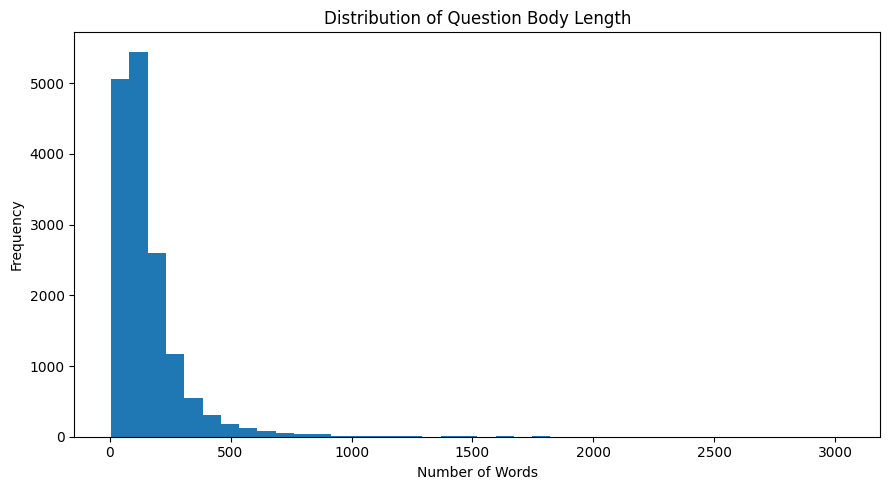

In [9]:
df["title_words"] = df["title"].str.split().str.len()
df["body_words"] = df["body"].str.split().str.len()

display(df[["title_words", "body_words"]].describe())

plt.figure(figsize=(9, 5))
plt.hist(df["body_words"], bins=40)
plt.title("Distribution of Question Body Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

## 7. Prepare the Training Dataset

The model is trained as a causal language model using the following prompt format:

`### Question: ...`

`### Answer: ...`

The Stack Overflow `title` is used as the question and the cleaned `body` is used as the response text, following the structure of the reference notebook.

In [10]:
# Keep only the fields required for training
train_df = df[["title", "body"]].copy()

# Convert back to a Hugging Face Dataset
train_dataset = Dataset.from_pandas(train_df, preserve_index=False)

print(train_dataset)

Dataset({
    features: ['title', 'body'],
    num_rows: 15722
})


## 8. Load GPT-2 Tokenizer

GPT-2 is used as the pre-trained causal language model. The EOS token is used as the padding token, matching the reference implementation.

In [11]:
MODEL_NAME = "gpt2"

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
tokenizer.pad_token = tokenizer.eos_token

print("Tokenizer loaded:", MODEL_NAME)
print("Vocabulary size:", tokenizer.vocab_size)
print("Pad token:", tokenizer.pad_token)

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Tokenizer loaded: gpt2
Vocabulary size: 50257
Pad token: <|endoftext|>


## 9. Tokenization

A maximum sequence length of 128 tokens is used to keep training feasible on a Colab T4 GPU.

Labels are copied from the input IDs because GPT-2 is trained using causal language modeling.

In [12]:
MAX_LENGTH = 128

def tokenize_function(examples):
    texts = [
        f"### Question: {question}\n### Answer: {answer}"
        for question, answer in zip(examples["title"], examples["body"])
    ]

    tokens = tokenizer(
        texts,
        truncation=True,
        padding="max_length",
        max_length=MAX_LENGTH
    )

    tokens["labels"] = [ids.copy() for ids in tokens["input_ids"]]
    return tokens

tokenized_dataset = train_dataset.map(
    tokenize_function,
    batched=True,
    remove_columns=train_dataset.column_names
)

print(tokenized_dataset)

Map:   0%|          | 0/15722 [00:00<?, ? examples/s]

Dataset({
    features: ['input_ids', 'attention_mask', 'labels'],
    num_rows: 15722
})


In [13]:
# Inspect one tokenized example
example = tokenized_dataset[0]

print("Input IDs:", example["input_ids"][:20])
print("Attention mask:", example["attention_mask"][:20])
print("Number of tokens:", len(example["input_ids"]))

Input IDs: [21017, 18233, 25, 1846, 499, 2989, 3141, 284, 651, 262, 749, 2274, 3275, 30, 198, 21017, 23998, 25, 1148, 612]
Attention mask: [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]
Number of tokens: 128


## 10. Configure GPT-2 with LoRA

LoRA (Low-Rank Adaptation) is used to fine-tune only a small number of additional parameters instead of updating the complete GPT-2 model.

This reduces GPU memory requirements and makes fine-tuning more practical on a T4 GPU.

In [14]:
!
!pip install --upgrade torchao

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

base_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME)
base_model.config.pad_token_id = tokenizer.pad_token_id

lora_config = LoraConfig(
    r=8,
    lora_alpha=32,
    target_modules=["c_attn", "c_proj", "c_fc"],
    lora_dropout=0.1,
    bias="none",
    task_type=TaskType.CAUSAL_LM
)

model = get_peft_model(base_model, lora_config)
model.to(device)

model.print_trainable_parameters()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 73.5 MB/s eta 0:00:00
  Attempting uninstall: torchao
    Found existing installation: torchao 0.10.0
    Uninstalling torchao-0.10.0:
      Successfully uninstalled torchao-0.10.0


model.safetensors: reconstructing file:   0%|          |  0.00B /  548MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

/usr/local/lib/python3.13/dist-packages/peft/tuners/lora/layer.py:2631: UserWarning: fan_in_fan_out is set to False but the target module is `Conv1D`. Setting fan_in_fan_out to True.
  warnings.warn(


trainable params: 1,179,648 || all params: 125,619,456 || trainable%: 0.9391


## 11. Fine-Tuning Configuration

The training configuration is designed for a Colab T4 GPU.

- Epochs: 5
- Batch size: 2
- Gradient accumulation: 4
- Learning rate: 5e-5
- FP16: enabled when CUDA is available
- LoRA: enabled

In [15]:
OUTPUT_DIR = "./industrygpt-it-lora"

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=5,
    per_device_train_batch_size=2,
    gradient_accumulation_steps=4,
    learning_rate=5e-5,
    weight_decay=0.01,
    logging_steps=50,
    save_steps=500,
    save_total_limit=2,
    fp16=torch.cuda.is_available(),
    report_to="none",
    push_to_hub=False,
    remove_unused_columns=False
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_dataset
)

print("Trainer configured.")

Trainer configured.


## 12. Train the IT Industry Bot

Run the following cell to start fine-tuning.

**Note:** Training time depends on the selected dataset size and available GPU.

In [16]:
train_result = trainer.train()

print("\nTraining completed.")
print("Training loss:", train_result.training_loss)

[transformers] `loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Step,Training Loss
50,3.897183
100,3.332411
150,3.224712
200,3.139497
250,3.160117
300,3.141953
350,3.140954
400,3.161031
450,3.058920
500,3.021999



Training completed.
Training loss: 3.001841351653649


## 13. Visualize Training Loss

The Trainer stores training history. A loss curve gives a simple view of how the training objective changes during fine-tuning.

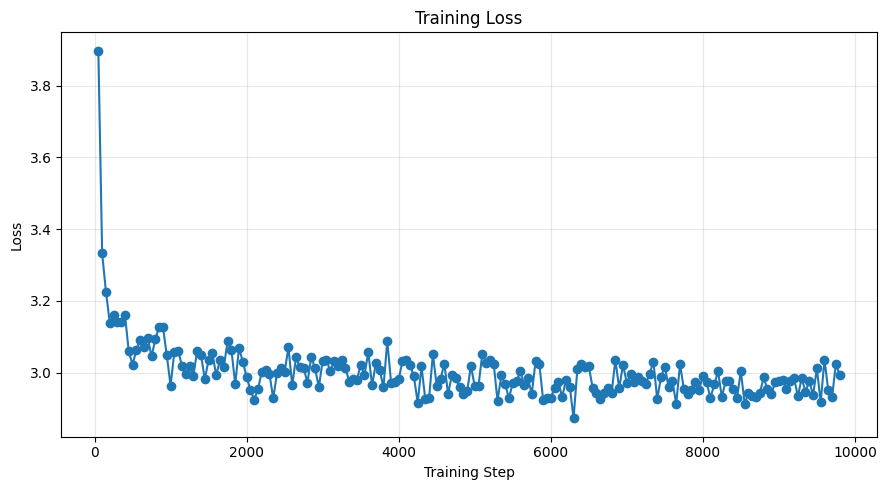

In [17]:
history = pd.DataFrame(trainer.state.log_history)

if "loss" in history.columns:
    loss_history = history.dropna(subset=["loss"])

    plt.figure(figsize=(9, 5))
    plt.plot(loss_history["step"], loss_history["loss"], marker="o")
    plt.title("Training Loss")
    plt.xlabel("Training Step")
    plt.ylabel("Loss")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("No loss history was recorded.")

## 14. Save the LoRA Adapter

Only the PEFT adapter needs to be saved because the GPT-2 base model can be loaded separately.

In [18]:
ADAPTER_DIR = "./industrygpt-it-lora"

model.save_pretrained(ADAPTER_DIR)
tokenizer.save_pretrained(ADAPTER_DIR)

print("LoRA adapter saved to:", ADAPTER_DIR)
print("Files:", os.listdir(ADAPTER_DIR))

LoRA adapter saved to: ./industrygpt-it-lora
Files: ['adapter_config.json', 'README.md', 'adapter_model.safetensors', 'checkpoint-9830', 'tokenizer_config.json', 'checkpoint-9500', 'tokenizer.json']


## 15. Load the Fine-Tuned Bot

For inference, the original GPT-2 model is loaded first and the trained LoRA adapter is attached to it.

In [19]:
inference_dtype = torch.float16 if torch.cuda.is_available() else torch.float32

base_model_inference = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    torch_dtype=inference_dtype
)

bot_model = PeftModel.from_pretrained(
    base_model_inference,
    ADAPTER_DIR
)

bot_model.eval()

print("Fine-tuned IT bot loaded successfully.")

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Fine-tuned IT bot loaded successfully.


In [20]:
generator = pipeline(
    "text-generation",
    model=bot_model,
    tokenizer=tokenizer,
    device=0 if torch.cuda.is_available() else -1
)

print("Text-generation pipeline ready.")

Text-generation pipeline ready.


## 16. Response Generation Function

The function below converts an IT question into the same prompt format used during training and generates a response.

Sampling parameters are included to provide varied responses.

In [21]:
def generate_bot_response(question, max_new_tokens=150):
    prompt = f"### Question: {question}\n### Answer:"

    result = generator(
        prompt,
        max_new_tokens=max_new_tokens,
        num_return_sequences=1,
        do_sample=True,
        top_k=50,
        top_p=0.95,
        temperature=0.7,
        pad_token_id=tokenizer.eos_token_id
    )

    generated_text = result[0]["generated_text"]

    if "### Answer:" in generated_text:
        answer = generated_text.split("### Answer:", 1)[1].strip()
    else:
        answer = generated_text.strip()

    return answer

## 17. Test the IndustryGPT Bot

The following questions cover common IT and software-development topics.

In [22]:
test_questions = [
    "How can I optimize a SQL query for a large dataset?",
    "What is containerization in software development?",
    "What are best practices for securing a web application?",
    "How does machine learning differ from deep learning?",
    "What are the principles of a RESTful API?"
]

for i, question in enumerate(test_questions, start=1):
    print("=" * 80)
    print(f"Question {i}: {question}")
    print("-" * 80)
    print(generate_bot_response(question))
    print()

[transformers] Passing `generation_config` together with generation-related arguments=({'pad_token_id', 'top_k', 'num_return_sequences', 'temperature', 'max_new_tokens', 'do_sample', 'top_p'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Question 1: How can I optimize a SQL query for a large dataset?
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=150) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer GPT2Tokenizer. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.
[transformers] Both `max_new_tokens` (=150) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


I am trying to optimize a SQL query for a large dataset. I am using a large dataset in my database. I have a dataset of 3.5 million records. I have a SQL query that says I want to make sure I get the number of columns in each row. I am using a SQL query that says I want to get the number of rows in each row. I have tried all the options for the query. I don't have an option for the option to optimize the query. How can I optimize the query?

Question 2: What is containerization in software development?
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=150) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


I'm trying to use a Java project that has a large number of containers. I'm using the Java Containerization Kit to build my software and I'm seeing a lot of containerization issues. I'm using a "containerize" package to create the container, which is actually a wrapper around a web interface. I'm not sure what containerization I'm talking about here. I've read some excellent articles and read a few tutorials, but it seems that it's not a good idea to create containers. I'm using a different approach: I'm using the java.util.Scanner class in my app, and I've got an empty interface that can be used to create containers. I'm trying to use a containerize package to use

Question 3: What are best practices for securing a web application?
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=150) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


I have a site that I need to log in to. I'm trying to figure out how to build an application that will be able to run on the client-server. I have set up an app.js file in the root of the root directory, but when I run it, the file opens with a warning that the file was not found. I want to do something similar to this: My app.js file contains a form. I'm trying to build a web application that I know will be able to run on the client-server. Is there any way to create a web application that will be able to run on the client-server? I'm curious if there is a way to secure a site that won't be able to

Question 4: How does machine learning differ from deep learning?
--------------------------------------------------------------------------------


[transformers] Both `max_new_tokens` (=150) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


I'm working with a large database and am having difficulty finding a meaningful way to train a machine learning algorithm. One of the key pieces of information is the number of variables that the machine learning algorithm can learn from. I'm trying to find a way to find the best way to train a machine learning algorithm that can learn from the input data. So far, I have found a number of interesting things about the deep learning approach. However, I'm not sure how to make it better. I'm trying to find a way to train a machine learning algorithm that can learn from the input data but that can't find the best way to train a machine learning algorithm that can learn from the input data. Is there a way to do this?

Question 5: What are the principles of a RESTful API?
--------------------------------------------------------------------------------
I have a RESTful API which allows for a user to send and receive messages from multiple accounts. The problem with this API is that it require

## 18. Interactive IT Chatbot

Use this section to ask your own IT/programming questions after the model has been trained.

In [23]:
question = input("Enter an IT-related question: ")

if question.strip():
    print("\nIndustryGPT:")
    print(generate_bot_response(question))
else:
    print("Please enter a question.")

Enter an IT-related question: what is Data Science?


[transformers] Both `max_new_tokens` (=150) and `max_length`(=50) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)



IndustryGPT:
I have a dataset that is a logarithmic function. It is like this: var x = { "name": "John", "age": "34", "gender": "M", "birthday": "May 1", "birthplace": "Cincinnati", "firstName": "John" }, "data": { "name": "John", "age": "34", "gender": "M", "birthday": "May 1", "birthplace": "Cincinnati", "firstName": "John" } I can find the following values for the x variables in the data: x = { "name": "John", "age": "34", "gender": "M", "birthday": "


## 19. Project Summary

### Industry
**Technology and Information Technology (IT)**

### Dataset
`pacovaldez/stackoverflow-questions`

### Base Model
**GPT-2**

### Fine-Tuning Method
**LoRA / PEFT**

### Main Processing
- Missing-value handling
- Duplicate removal
- HTML removal
- Whitespace normalization
- Dataset sampling for Colab resource constraints
- Prompt-based causal language modeling

### Training
The model is fine-tuned using Hugging Face `Trainer` with a small batch size, gradient accumulation, and optional FP16 mixed precision.

### Bot
The trained LoRA adapter is attached to GPT-2 and exposed through a Transformers text-generation pipeline.

### Demonstration
The final bot is tested using programming, SQL, APIs, security, machine learning, and software-development questions.

## Conclusion

This project demonstrates an end-to-end workflow for creating an **industry-specific LLM bot** using a pre-trained model, domain-specific Stack Overflow data, and parameter-efficient fine-tuning. The approach is designed to be practical on limited GPU resources while providing a foundation for further improvement with larger datasets, better evaluation, and more advanced models.

## 20. Important Limitations and Future Improvements

### Current limitations
- GPT-2 is a relatively small and older causal language model.
- The training sample is intentionally limited for Colab resource constraints.
- Sequence length is limited to 128 tokens.
- The model is trained on question/body text rather than curated human-written answer pairs.
- Generated responses should be evaluated before being used in production.

### Future improvements
- Use a larger, instruction-tuned open-source model.
- Increase the training dataset when GPU resources permit.
- Use longer context windows.
- Create high-quality question-answer pairs.
- Add a validation/test evaluation set.
- Add automated response-quality metrics.
- Add retrieval-augmented generation (RAG) using technical documentation.
- Deploy the trained bot as a web API or chat interface.